In [4]:
import pandas as pd
import numpy as np
import random

# --- CONFIGURAÇÃO DO GERADOR ---
produtos = {
    'Notebook Dell': 3500.00,
    'Mouse Logi': 150.00,
    'Monitor LG': 1200.00,
    'Teclado Mecânico': 300.00
}
cidades = ['São Paulo', 'Rio de Janeiro', 'Belo Horizonte', 'Curitiba']

dados = []

# Gerando 500 linhas de vendas
for _ in range(500):
    prod = random.choice(list(produtos.keys()))
    cidade = random.choice(cidades)
    qtd = random.randint(1, 3)
    preco_base = produtos[prod]
    
    # ⚠️ INTRODUZINDO ERROS PROPOSITAIS (SUJEIRA) ⚠️
    
    # 1. Erro de Digitação na Cidade (10% de chance)
    if random.random() < 0.1:
        cidade = cidade.lower() # Ex: 'são paulo' (minúsculo)
        
    # 2. Transformando Dinheiro em Texto (O maior vilão)
    # O Python não soma "R$ 3.500,00". Ele só soma 3500.00
    valor_total = preco_base * qtd
    valor_sujo = f"R$ {valor_total:,.2f}" # Vira texto com símbolo
    valor_sujo = valor_sujo.replace(",", "X").replace(".", ",").replace("X", ".") # Formato PT-BR bagunçado
    
    # 3. Criando Buracos (Datas vazias)
    data = '2026-02-07'
    if random.random() < 0.05:
        data = np.nan # Valor Nulo (Not a Number)

    dados.append([data, prod, cidade, qtd, valor_sujo])

# Criando o DataFrame (A Tabela)
df = pd.DataFrame(dados, columns=['Data', 'Produto', 'Cidade', 'Qtd', 'Valor_Total'])

# Duplicando linhas de propósito para termos o que limpar
df = pd.concat([df, df.sample(20)]) 

print("✅ Tabela Bagunçada Gerada com Sucesso!")

✅ Tabela Bagunçada Gerada com Sucesso!


In [5]:
# 1. Mostra as 5 primeiras linhas
display(df.head())

# 2. Mostra o Raio-X Técnico (Tipos de dados)
df.info()

,Data,Produto,Cidade,Qtd,Valor_Total
0,2026-02-07,Monitor LG,Curitiba,2,"R$ 2.400,00"
1,2026-02-07,Teclado Mecânico,Curitiba,1,"R$ 300,00"
2,2026-02-07,Mouse Logi,Curitiba,1,"R$ 150,00"
3,2026-02-07,Teclado Mecânico,Curitiba,3,"R$ 900,00"
4,2026-02-07,Notebook Dell,rio de janeiro,1,"R$ 3.500,00"


<class 'pandas.core.frame.DataFrame'>
Index: 520 entries, 0 to 31
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Data         491 non-null    object
 1   Produto      520 non-null    object
 2   Cidade       520 non-null    object
 3   Qtd          520 non-null    int64 
 4   Valor_Total  520 non-null    object
dtypes: int64(1), object(4)
memory usage: 24.4+ KB


In [6]:
# Verifica quantas linhas temos agora
print(f"Linhas antes da limpeza: {df.shape[0]}")

# O comando mágico que apaga as cópias
df.drop_duplicates(inplace=True)

# Verifica se caiu para 500 (ou perto disso, caso o gerador tenha criado duplicatas naturais)
print(f"Linhas depois da limpeza: {df.shape[0]}")

Linhas antes da limpeza: 520
Linhas depois da limpeza: 102


In [7]:
# 1. Mostra a bagunça atual
print("Cidades ANTES da limpeza:")
print(df['Cidade'].value_counts())

# 2. Transforma tudo para "Title Case" (1ª letra Maiúscula)
df['Cidade'] = df['Cidade'].str.title()

# 3. Confere o resultado
print("\nCidades DEPOIS da limpeza:")
print(df['Cidade'].value_counts())

Cidades ANTES da limpeza:
Cidade
Belo Horizonte    20
São Paulo         18
Rio de Janeiro    16
Curitiba          15
curitiba           9
rio de janeiro     9
belo horizonte     9
são paulo          6
Name: count, dtype: int64

Cidades DEPOIS da limpeza:
Cidade
Belo Horizonte    29
Rio De Janeiro    25
Curitiba          24
São Paulo         24
Name: count, dtype: int64


In [8]:
# Preenche os vazios com "Data Desconhecida"
df['Data'] = df['Data'].fillna('Data Desconhecida')

# Confirma se limpou tudo (o resultado deve ser 0)
print("Buracos restantes:", df['Data'].isnull().sum())

Buracos restantes: 0


In [9]:
# 1. Remove o "R$" e espaços
df['Valor_Total'] = df['Valor_Total'].str.replace('R$', '', regex=False)

# 2. Tira o ponto de milhar (O Python não usa ponto para separar milhar)
df['Valor_Total'] = df['Valor_Total'].str.replace('.', '', regex=False)

# 3. Troca a vírgula por ponto (Para o Python entender os centavos)
df['Valor_Total'] = df['Valor_Total'].str.replace(',', '.', regex=False)

# 4. Converte finalmente para Número (Float)
df['Valor_Total'] = df['Valor_Total'].astype(float)

# Mostra o tipo de dado final (deve aparecer float64)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102 entries, 0 to 488
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Data         102 non-null    object 
 1   Produto      102 non-null    object 
 2   Cidade       102 non-null    object 
 3   Qtd          102 non-null    int64  
 4   Valor_Total  102 non-null    float64
dtypes: float64(1), int64(1), object(3)
memory usage: 4.8+ KB


In [10]:
# 1. Faturamento Total Real
faturamento = df['Valor_Total'].sum()

# 2. Ranking de Cidades (Quem comprou mais?)
ranking_cidades = df.groupby('Cidade')['Valor_Total'].sum().sort_values(ascending=False)

print(f"💰 Faturamento Total: R$ {faturamento:,.2f}")
print("-" * 30)
print("🏆 Ranking de Cidades (Por valor vendido):")
print(ranking_cidades)

💰 Faturamento Total: R$ 243,800.00
------------------------------
🏆 Ranking de Cidades (Por valor vendido):
Cidade
Belo Horizonte    64200.0
Rio De Janeiro    63850.0
São Paulo         58900.0
Curitiba          56850.0
Name: Valor_Total, dtype: float64


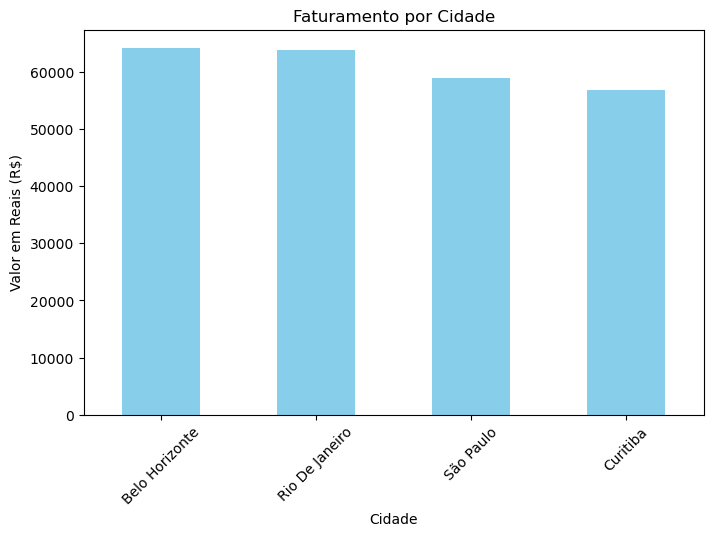

In [11]:
# Importa a biblioteca de gráficos
import matplotlib.pyplot as plt

# Cria o gráfico
ranking_cidades.plot(kind='bar', color='skyblue', figsize=(8,5))

# Coloca títulos
plt.title('Faturamento por Cidade')
plt.ylabel('Valor em Reais (R$)')
plt.xlabel('Cidade')
plt.xticks(rotation=45) # Deixa os nomes meio de lado pra ler melhor

# Mostra o desenho
plt.show()

In [13]:
# Salva a tabela limpa em um arquivo Excel
# index=False serve para não salvar a coluna de numeração (0, 1, 2...)
df.to_excel("relatorio_vendas_final.xlsx", index=False)

print("✅ Arquivo 'relatorio_vendas_final.xlsx' criado com sucesso na sua pasta!")

✅ Arquivo 'relatorio_vendas_final.xlsx' criado com sucesso na sua pasta!


In [14]:
# Lê o arquivo que você acabou de criar e mostra na tela
df_final = pd.read_excel("relatorio_vendas_final.xlsx")
display(df_final)

,Data,Produto,Cidade,Qtd,Valor_Total
0,2026-02-07,Monitor LG,Curitiba,2,2400
1,2026-02-07,Teclado Mecânico,Curitiba,1,300
2,2026-02-07,Mouse Logi,Curitiba,1,150
3,2026-02-07,Teclado Mecânico,Curitiba,3,900
4,2026-02-07,Notebook Dell,Rio De Janeiro,1,3500
...,...,...,...,...,...
97,Data Desconhecida,Mouse Logi,Rio De Janeiro,3,450
98,Data Desconhecida,Monitor LG,Belo Horizonte,3,3600
99,Data Desconhecida,Teclado Mecânico,Belo Horizonte,2,600
100,Data Desconhecida,Mouse Logi,Belo Horizonte,1,150


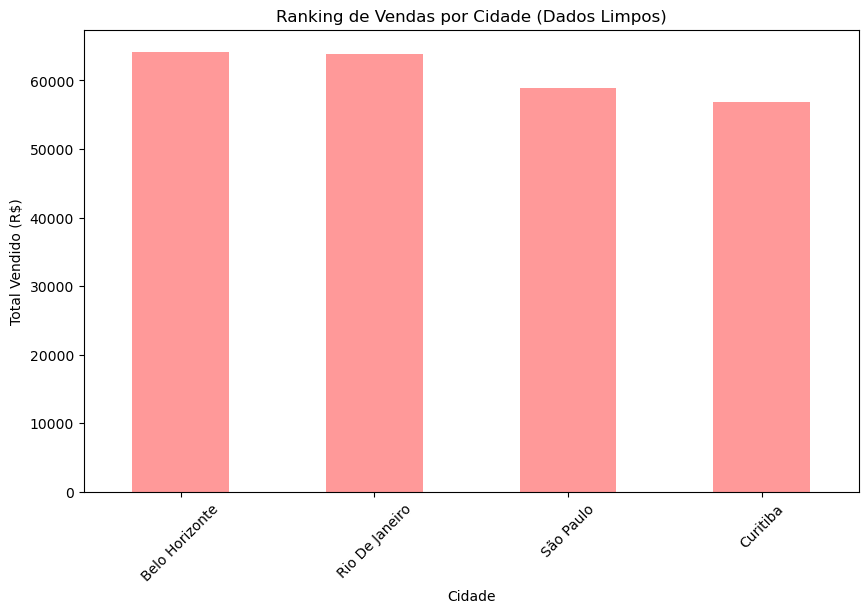

✅ A imagem 'meu_grafico_vendas.png' foi salva na sua pasta!


In [15]:
import matplotlib.pyplot as plt

# 1. Cria o gráfico de novo
ranking_cidades.plot(kind='bar', color='#ff9999', figsize=(10,6))
plt.title('Ranking de Vendas por Cidade (Dados Limpos)')
plt.ylabel('Total Vendido (R$)')
plt.xlabel('Cidade')
plt.xticks(rotation=45)

# 2. SALVA O GRÁFICO COMO IMAGEM (PNG)
plt.savefig("meu_grafico_vendas.png", bbox_inches='tight') # bbox_inches garante que não corte os nomes

# 3. Mostra na tela
plt.show()

print("✅ A imagem 'meu_grafico_vendas.png' foi salva na sua pasta!")